In [210]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import matplotlib.pyplot as plt
import statsmodels.api as sm
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d as m3d
import numpy as np
from scipy import stats
from statsmodels.formula.api import ols
from patsy.contrasts import Treatment
from scipy.stats import norm
import requests
import pyreadr
from pingouin import ancova
import seaborn as sns
from matplotlib.colors import Normalize
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from itertools import combinations
from patsy import dmatrix
import pyreadr
import statsmodels.api as sm
import requests
from statsmodels.nonparametric.smoothers_lowess import lowess


In [211]:
url = (
    "https://raw.githubusercontent.com/fx-biocoder/"
    "Regresion-lineal-multiple/refs/heads/main/RIKZ.csv"
)
rikz = pd.read_csv(url)

print(rikz.shape)
print('Columns: ',rikz.columns)
print(rikz.head())
print(len(rikz))

(45, 5)
Columns:  Index(['richness', 'angle', 'NAP', 'grainsize', 'humus'], dtype='object')
   richness  angle    NAP  grainsize  humus
0        11     96  0.045      222.5   0.05
1        10     96 -1.036      200.0   0.30
2        13     96 -1.336      194.5   0.10
3        11     96  0.616      221.0   0.15
4        10     96 -0.684      202.0   0.05
45


Now, we want to include 2 predictors ( + intercept)
<br>
$Richness_i = \beta_0 + \beta_1NAP + \beta_2Humus + \epsilon_i$

In [212]:
X = rikz[['NAP','humus']]

y = rikz[['richness']]

X = sm.add_constant(X)

model = sm.OLS(y,X).fit()

predicted = model.fittedvalues
    
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               richness   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.369
Method:                 Least Squares   F-statistic:                     13.87
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           2.37e-05
Time:                        14:34:42   Log-Likelihood:                -124.39
No. Observations:                  45   AIC:                             254.8
Df Residuals:                      42   BIC:                             260.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.4592      0.830      6.575      0.0

Instead of a best-fit line through data in two dimensions, we now have a best fit plane through data in three dimensions

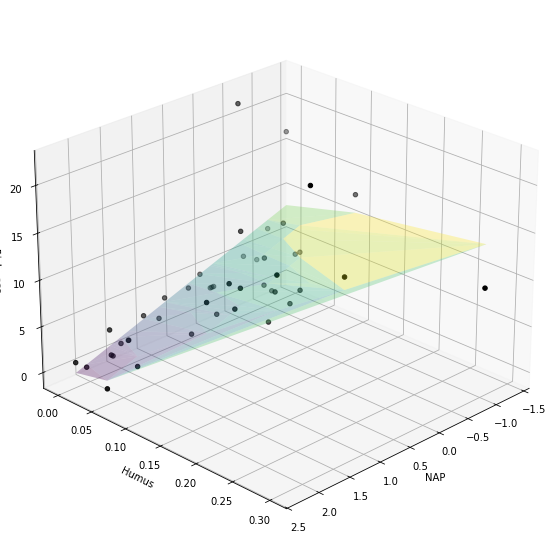

In [213]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection="3d")

x = rikz["NAP"].to_numpy()
y = rikz["humus"].to_numpy()
observed = rikz["richness"].to_numpy()
fitted = np.asarray(predicted)


ax.plot_trisurf(
    x,
    y,
    fitted,
    alpha=0.3,
    cmap="viridis"
)
ax.scatter(x, y, observed, marker="o", label="Observed", color='black')

ax.set_xlabel("NAP")
ax.set_ylabel("Humus")
ax.set_zlabel("Richness")
ax.view_init(elev=25, azim=45)


plt.show()

Our interpretation of regression parameters is similar to that in simple linear regression, except now we have to consider a change in one variable while holding other variables in the model constant:

- $\beta_0$ describes the level of Richness if Humus and NAP are both simultaneously equal 0.
- $\beta_1$ describes the change in Richness for every 1 unit increase in NAP while holding Humus constant.
- $\beta_2$ describes the change in Richness for every 1 unit increase in Humus while holding NAP constant.

Although it is easy to fit multiple regression models with more than two predictors, we will no longer be able to visualize the fitted model in higher dimensions. Before we consider more complex models, however, we will first explore how to incorporate categorical predictors into our models.



### Categorical Predictors : T-test as a regression ###

Here, we will consider mandible lengths (in mm) of 10 male and 10 female golden jackal (Canis aureus) specimens from the British Museum

In [214]:
males = np.array([120, 107, 110, 116, 114, 111, 113, 117, 114, 112])
females = np.array([110, 111, 107, 108, 110, 105, 107, 106, 111, 111])

We might ask: Do males and females have, on average, different mandible lengths? Let’s consider a formal hypothesis test and confidence interval for the difference in population means: $H_0 : \mu_m = \mu_f \space\space $ versus $ \space \space  H_1: \mu_m \neq \mu_f $ where  
$\mu_f$ and $\mu_m$ represent population means for male and female jackals, respectively.

If we assume that mandible lengths are Normally distributed in the population1, and that the variance for male and female jaw lengths are about the same2, then we can use the following code to conduct a t-test for a difference in means:

In [215]:
t_val, p_val = stats.ttest_ind(males, females)
print(f"t-stat: {t_val}")
print(f"p-value: {p_val}")

t-stat: 3.4843242131699643
p-value: 0.0026472674183380626


In [216]:
df = len(males) + len(females) - 2
alpha = 0.05

In [217]:
crit_t = stats.t.ppf(1 - alpha/2, df)
print(f"Critical t-value: {crit_t}")

Critical t-value: 2.10092204024096


In [218]:
print('T-test Result:')
if np.abs(t_val) >crit_t:
    print('Significant difference found.')
else:
    print('No significant difference.')

T-test Result:
Significant difference found.


We can also conduct this same test using a regression model with sex as the only predictor. First, we will have to create a data.frame with mandible lengths (quantitative) and sex (categorical).

In [219]:
jackal_data = pd.DataFrame({'jaws': np.concatenate([males,females]), 'sex': np.repeat(['m','f'], [len(males),len(females)])})
jackal_data

,jaws,sex
0,120,m
1,107,m
2,110,m
3,116,m
4,114,m
5,111,m
6,113,m
7,117,m
8,114,m
9,112,m


Contrast coding determines how a categorical variable is represented by regression coefficients.

With K categories, a model containing an intercept normally uses:

- one reference category;
- K−1 coefficients.

In [220]:
X = jackal_data[['sex']]

y = jackal_data['jaws']

model_j = ols("jaws ~ C(sex, Treatment(reference='f'))", data=jackal_data).fit()

predicted = model_j.fittedvalues

print(model_j.summary())

                            OLS Regression Results                            
Dep. Variable:                   jaws   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.370
Method:                 Least Squares   F-statistic:                     12.14
Date:                Sun, 23 Aug 2026   Prob (F-statistic):            0.00265
Time:                        14:34:43   Log-Likelihood:                -49.826
No. Observations:                  20   AIC:                             103.7
Df Residuals:                      18   BIC:                             105.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [221]:
model_cell_means = ols("jaws ~ C(sex) - 1", data=jackal_data).fit()
    
print(model_cell_means.summary())

                            OLS Regression Results                            
Dep. Variable:                   jaws   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.370
Method:                 Least Squares   F-statistic:                     12.14
Date:                Sun, 23 Aug 2026   Prob (F-statistic):            0.00265
Time:                        14:34:43   Log-Likelihood:                -49.826
No. Observations:                  20   AIC:                             103.7
Df Residuals:                      18   BIC:                             105.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
C(sex)[f]    108.6000      0.974    111.486      0.0

### Comparing assumptions: Linear model and t-test ###

What are the assumptions of our model for the jaw lengths? Well, they are the same ones that we have for fitting linear regression models with continuous predictors:

constant variance of the errors (i.e., the two groups are assumed to have equal variance,  
$\sigma^2$
 )
the residuals, and by extension, the data within each group, are Normally distributed
These are the same assumptions of the two-sample t-test. Let’s see if they are reasonable by creating side-by-side histograms with a Normal density overlaid (Figure 3.4).

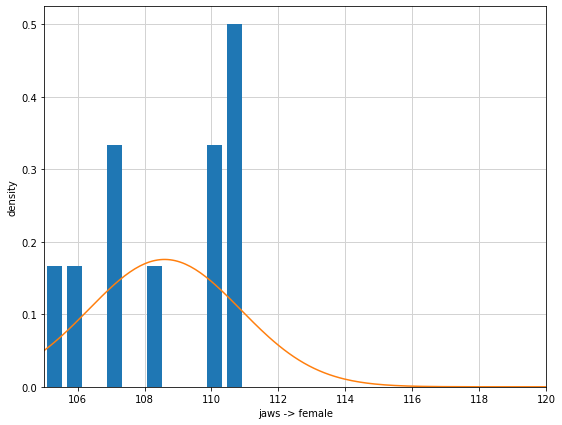

In [222]:
female = jackal_data.loc[jackal_data['sex']=='f','jaws']
mu = female.mean()
sigma = female.std(ddof=1)
min_all = jackal_data['jaws'].min()
max_all = jackal_data['jaws'].max()
X = np.linspace(min_all, max_all, 200)
y = norm.pdf(X, loc = mu, scale = sigma)
plt.figure(figsize=(9,7))
plt.grid(color='lightgray', linestyle='-', linewidth=1, zorder=1)
plt.hist(female, density='True', rwidth=0.75, zorder=2)
plt.plot(X,y)
plt.xlim([min_all, max_all])
plt.ylabel('density')
plt.xlabel('jaws -> female')
plt.show()

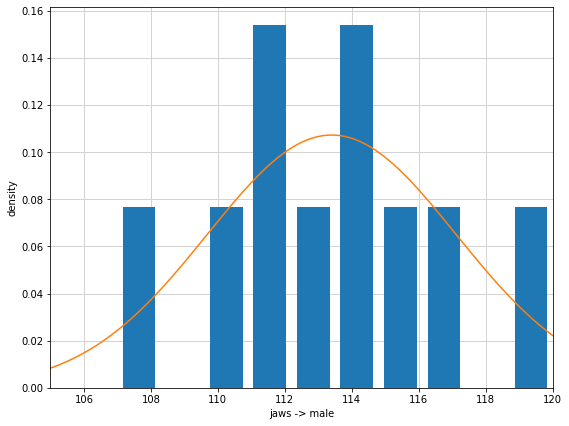

In [223]:
male = jackal_data.loc[jackal_data['sex']=='m','jaws']
mu = male.mean()
sigma = male.std(ddof=1)
X = np.linspace(min_all, max_all, 200)
y = norm.pdf(X, loc = mu, scale = sigma)
plt.figure(figsize=(9,7))
plt.grid(color='lightgray', linestyle='-', linewidth=1, zorder=1)
plt.hist(male, density='True', rwidth=0.75, zorder=2)
plt.plot(X,y)
plt.xlim([min_all, max_all])
plt.ylabel('density')
plt.xlabel('jaws -> male')
plt.show()

In [224]:
url = (
    "https://raw.githubusercontent.com/jfieberg/"
    "Data4Ecologists/main/data/RIKZdat.rda"
)

with open("RIKZdat.rda", "wb") as file:
    file.write(requests.get(url).content)

rikz_full = pyreadr.read_r("RIKZdat.rda")["RIKZdat"]

In [225]:
print(rikz_full.columns)

Index(['week', 'exposure', 'NAP', 'humus', 'Beach', 'Richness'], dtype='object')


In [226]:
print(rikz_full.week.value_counts())

week
2    15
3    15
1    10
4     5
Name: count, dtype: int64


__Aside__: historically, statistical inference from a model with a single categorical variable and a continuous variable (and no interaction between the two) was referred to as an analysis of covariance or ANCOVA. We could also have considered a model with only week.cat (and not NAP), which would have led to an analysis of variance or ANOVA. This distinction (between ANOVA, ANCOVA, and other regression models) is more historical than practical, however, as each of these approaches shares the same underlying statistical machinery

In [227]:
model_full = ols("Richness ~ NAP + C(week, Treatment(reference=1))", data=rikz_full).fit()
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:               Richness   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     20.86
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           2.37e-09
Time:                        14:34:44   Log-Likelihood:                -110.45
No. Observations:                  45   AIC:                             230.9
Df Residuals:                      40   BIC:                             239.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


In [228]:
rikz_ancova = ancova(data=rikz_full, dv='Richness', between='week', covar='NAP')
print(rikz_ancova)

     Source          SS  DF          F     p_unc       np2
0      week  387.111886   3  14.457822  0.000002  0.520231
1       NAP  210.329915   1  23.566151  0.000019  0.370734
2  Residual  357.003418  40        NaN       NaN       NaN


In [229]:
predicted = model_full.predict()
print(predicted)

[11.26551727 13.72020722 14.40143477  9.96891416 12.92090022  8.66549878
  9.50567943  9.92576975 11.22918514 14.39689326  5.95881235  0.35003884
  4.19897451  4.83705765  3.36333538 -0.272149    3.8106748   2.69800313
  0.63842517  5.5841372   6.23691749  9.91554628  7.11797179  5.07883065
  8.65073379  6.50224636  5.9799719   0.14412254  7.21753529  3.45034692
  1.73747228 -0.31302265  0.6202591   3.87879756  2.90918368  1.39531047
  6.04128238  7.47186024  4.803719    0.53015148  5.99813797  4.97629664
  5.19428946  0.06918751  3.22554183]


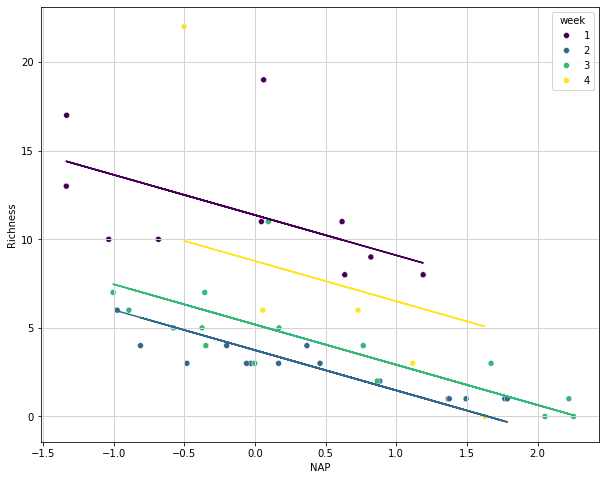

In [230]:

p = model_full.params
se = model_full.bse

intercept = p["Intercept"]
slope_week2 = p["Intercept"] + p["C(week, Treatment(reference=1))[T.2]"]
slope_week3 = p["Intercept"] + p["C(week, Treatment(reference=1))[T.3]"]
slope_week4 = p["Intercept"] + p["C(week, Treatment(reference=1))[T.4]"]

std_err_intercept = se['Intercept']
std_err_week1 = se["C(week, Treatment(reference=1))[T.2]"]
std_err_week2 = se["C(week, Treatment(reference=1))[T.3]"]
std_err_week3 = se["C(week, Treatment(reference=1))[T.4]"]

nap_slope = p["NAP"]

X1 = rikz_full[rikz_full['week']==1]['NAP']
X2 = rikz_full[rikz_full['week']==2]['NAP']
X3 = rikz_full[rikz_full['week']==3]['NAP']
X4 = rikz_full[rikz_full['week']==4]['NAP']

line1 = intercept + (X1 * nap_slope)
line2 = slope_week2 + (X2 * nap_slope)
line3 = slope_week3 + (X3 * nap_slope)
line4 = slope_week4 + (X4 * nap_slope)

weeks = [1, 2, 3, 4]

cmap = plt.colormaps["viridis"]
norm = Normalize(vmin=1, vmax=4)

week_colors = {
    week: cmap(norm(week))
    for week in weeks
}
plt.figure(figsize=(10,8))
sns.scatterplot(data=rikz_full, x='NAP', y='Richness', hue='week', palette='viridis')
plt.plot(X1, line1, color = week_colors[1])
plt.plot(X2, line2, color = week_colors[2])
plt.plot(X3, line3, color = week_colors[3])
plt.grid(color='lightgray', linestyle='-', linewidth=1)
plt.plot(X4, line4, color = week_colors[4])
plt.show()

#### Means Coding ####
We can fit the same model using means coding by removing the intercept:

In [231]:
model_cell_means = ols("Richness ~ NAP + C(week, Treatment) - 1 ", data=rikz_full).fit()
print(model_cell_means.summary())

                            OLS Regression Results                            
Dep. Variable:               Richness   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     20.86
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           2.37e-09
Time:                        14:34:44   Log-Likelihood:                -110.45
No. Observations:                  45   AIC:                             230.9
Df Residuals:                      40   BIC:                             239.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
C(week, Treatment)[1]    11.36

We see that the coefficient for week.cat1 is identical to the intercept in the effects model, since week 1 is the reference level in that model. In addition, the other coefficients for the week.cat variables represent the intercepts in the other weeks. If we look at the design matrix for our same 4 observations, we see 4 separate dummy variables are created for each week and that the intercept column has been removed.

#### Model with interactions ####
Adding an interaction means  that one predictor's effect or slope can depend on another predictor, in our case, each week can have a different relationship with NAP.

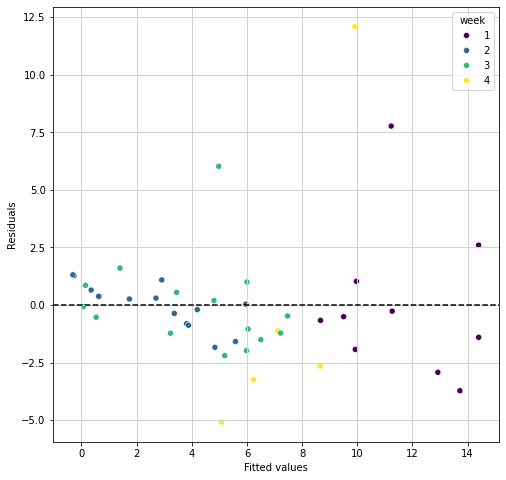

In [232]:
plt.figure(figsize=(8, 8))
sns.scatterplot(
    x=model_full.fittedvalues,
    y=model_full.resid,
    hue=rikz_full["week"],
    palette='viridis'
)

plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.grid(color='lightgray', linestyle='-', linewidth=1)
plt.show()

This plot seems to suggest that the residuals increase in variance with higher fitted values (this is common when modeling count data). There are also a few residuals with really high absolute values - look at weeks 1 and 4. In any case looking at that plot let’s assume you have a reason to believe the effect of NAP varies from week to week. If this were the case, we might consider adding an interaction between NAP and week category.

#### Effects Coding ####

Dummy coding is particularly useful when we have a group we would like to use for comparison with other groups. But what if we do not have one? 

In [233]:
model_with_interactions = ols("Richness ~ NAP * (C(week) -1)", data=rikz_full).fit()
print(model_with_interactions.summary())

                            OLS Regression Results                            
Dep. Variable:               Richness   R-squared:                       0.800
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     21.11
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           3.94e-11
Time:                        14:34:45   Log-Likelihood:                -99.622
No. Observations:                  45   AIC:                             215.2
Df Residuals:                      37   BIC:                             229.7
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           11.4056      0.777  

In [234]:
X = pd.DataFrame(
    model_with_interactions.model.exog, #our predictors
    columns = model_with_interactions.model.exog_names,
    index = model_with_interactions.model.data.row_labels
)
X.head()

,Intercept,C(week)[T.2],C(week)[T.3],C(week)[T.4],NAP,NAP:C(week)[T.2],NAP:C(week)[T.3],NAP:C(week)[T.4]
0,1.0,0.0,0.0,0.0,0.045,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,-1.036,-0.0,-0.0,-0.0
2,1.0,0.0,0.0,0.0,-1.336,-0.0,-0.0,-0.0
3,1.0,0.0,0.0,0.0,0.616,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,-0.684,-0.0,-0.0,-0.0


In [235]:
y = pd.Series(
    model_with_interactions.model.endog, # richness
    name = model_with_interactions.model.endog_names,
    index = model_with_interactions.model.data.row_labels
)
y.head()

0    11.0
1    10.0
2    13.0
3    11.0
4    10.0
Name: Richness, dtype: float64

Here, we see that we added 3 new predictors to our design matrix last seen in Section 3.7. These columns are formed by multiplying our original 3 dummy variables (indicating weeks 2, 3, and 4) by NAP. 

In [236]:
model_with_interactions.params

Intercept           11.405614
C(week)[T.2]        -8.040293
C(week)[T.3]        -6.371540
C(week)[T.4]         1.377214
NAP                 -1.900156
NAP:C(week)[T.2]     0.425579
NAP:C(week)[T.3]    -0.013442
NAP:C(week)[T.4]    -7.000022
dtype: float64

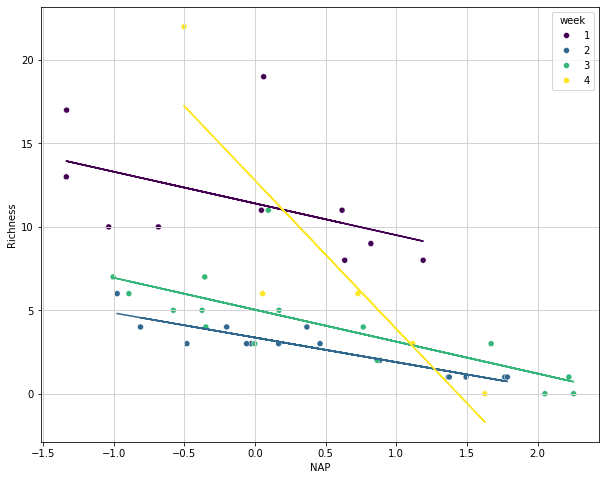

In [237]:
p = model_with_interactions.params

intercept_w1 = p['Intercept']
intercept_w2 = p['Intercept']+ p['C(week)[T.2]']
intercept_w3 = p['Intercept'] + p['C(week)[T.3]']
intercept_w4 = p['Intercept'] + p['C(week)[T.4]']
 
slope_w1 = p['NAP']
slope_w2 = p['NAP'] + p['NAP:C(week)[T.2]']
slope_w3 = p['NAP'] + p['NAP:C(week)[T.3]']
slope_w4 = p['NAP'] + p['NAP:C(week)[T.4]']

X1 = rikz_full[rikz_full['week']==1]['NAP']
X2 = rikz_full[rikz_full['week']==2]['NAP']
X3 = rikz_full[rikz_full['week']==3]['NAP']
X4 = rikz_full[rikz_full['week']==4]['NAP']

y_week1 = intercept_w1 + slope_w1 * X1
y_week2 = intercept_w2 + slope_w2 * X2
y_week3 = intercept_w3 + slope_w3 * X3
y_week4 = intercept_w4 + slope_w4 * X4


plt.figure(figsize=(10,8))
sns.scatterplot(data=rikz_full, x='NAP', y='Richness', hue='week', palette='viridis')
plt.plot(X1, y_week1, color = week_colors[1])
plt.plot(X2, y_week2, color = week_colors[2])
plt.plot(X3, y_week3, color = week_colors[3])
plt.plot(X4, y_week4 , color = week_colors[4])
plt.grid(color='lightgray', linestyle='-', linewidth=1)
plt.show()

#### Model With Means ####

The key idea is that this model is being reparameterized so that the coefficients directly represent the mean richness for each week/category, rather than using week 1 as the reference category. To fit the means parameterization of the model, we need to drop the columns of the design matrix associated with the intercept and slope for week 1 using the following syntax:

In [238]:
model_inter_means = ols("Richness ~ NAP * C(week) - 1 - NAP", data=rikz_full).fit()
print(model_inter_means.summary())

                            OLS Regression Results                            
Dep. Variable:               Richness   R-squared:                       0.800
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     21.11
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           3.94e-11
Time:                        14:34:45   Log-Likelihood:                -99.622
No. Observations:                  45   AIC:                             215.2
Df Residuals:                      37   BIC:                             229.7
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
C(week)[1]        11.4056      0.777     14.

#### Creating flexible models with dummy variables ####

After looking at the terms for the interactios model and also noting that the interaction terms for weeks 2 and 3 are not significantly different from 0 in the effects model, we might decide that we want to fit a model that allows each week to have its own intercept, but that the effect of NAP is the same in weeks 1-3 and differs only in week 4. If we understand how categorical variables are encoded in regression models, we can fit this model quite easily. We need to include week.cat to allow each week to have its own intercept. We also create a single dummy variable (equal to 1 if week is equal to 4 and 0 otherwise) and include the interaction of this dummy variable with NAP:

In [239]:
model_w4  = ols("Richness ~ NAP * C(week) + NAP:I(week == 4)", data=rikz_full).fit()
print(model_w4.summary())

                            OLS Regression Results                            
Dep. Variable:               Richness   R-squared:                       0.800
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     21.11
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           3.94e-11
Time:                        14:34:45   Log-Likelihood:                -99.622
No. Observations:                  45   AIC:                             215.2
Df Residuals:                      37   BIC:                             229.7
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

Weeks 1, 2, and 3 have the same NAP slope, while week 4 is allowed to have a different slope.

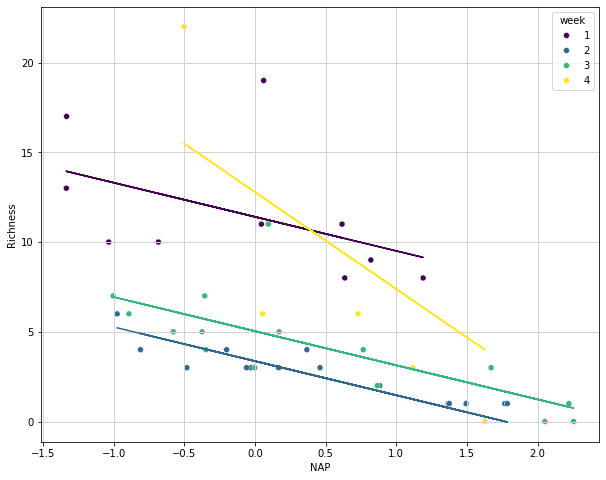

In [240]:
p = model_w4.params

intercept_w1 = p['Intercept']
intercept_w2 = p['Intercept']+ p['C(week)[T.2]']
intercept_w3 = p['Intercept'] + p['C(week)[T.3]']
intercept_w4 = p['Intercept'] + p['C(week)[T.4]']

slope = p['NAP']
slope_w4 = p['NAP'] + p['NAP:C(week)[T.4]']

X1 = rikz_full[rikz_full['week']==1]['NAP']
X2 = rikz_full[rikz_full['week']==2]['NAP']
X3 = rikz_full[rikz_full['week']==3]['NAP']
X4 = rikz_full[rikz_full['week']==4]['NAP']


y_week1 = intercept_w1 + slope * X1
y_week2 = intercept_w2 + slope * X2
y_week3 = intercept_w3 + slope * X3
y_week4 = intercept_w4 + slope_w4 * X4


plt.figure(figsize=(10,8))
sns.scatterplot(data=rikz_full, x='NAP', y='Richness', hue='week', palette='viridis')
plt.plot(X1, y_week1, color = week_colors[1])
plt.plot(X2, y_week2, color = week_colors[2])
plt.plot(X3, y_week3, color = week_colors[3])
plt.plot(X4, y_week4 , color = week_colors[4])
plt.grid(color='lightgray', linestyle='-', linewidth=1)
plt.show()

Although these results may look convincing, we arrived at this result in a very data-driven way. As we will discuss in Section 8, it is easy to develop models that fit your data well but that perform poorly when applied to new data. In general, you should be skeptical of relationships discovered based on intensive data exploration that were not expected a priori. Also, remember that this is an unbalanced design, with only 5 observations during week 4. Hence, this interaction model should be interpreted with great caution. It is quite possible that we are just fitting a model that explains noise in the data. Note, for example, the largest observed species richness value is associated with week 4 (Figure 3.6). This point could be the result of measurement error or some other factor that we have not accounted for in our model and the sole reason for the “need” for the interaction. In addition, if we plot residuals versus fitted values, we still see there are several large outliers in our residuals. So issues remain with our model that warrant further consideration.

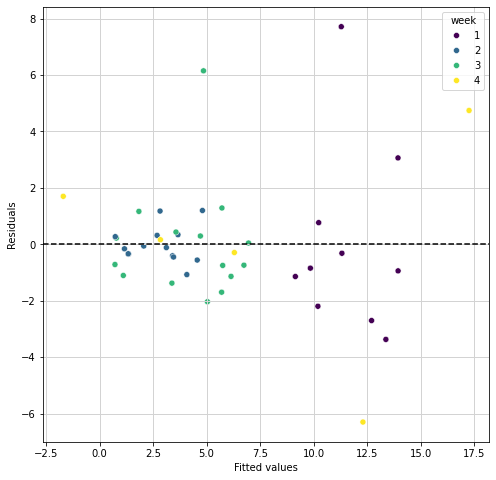

In [241]:

plt.figure(figsize=(8, 8))
sns.scatterplot(
    x=model_w4.fittedvalues,
    y=model_w4.resid,
    hue=rikz_full["week"],
    palette='viridis'
)

plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.grid(color='lightgray', linestyle='-', linewidth=1)
plt.show()

#### Pairwise comparisons ####

In [242]:
model_enc = model_w4  = ols("Richness ~ NAP + exposure +  C(week)", data=rikz_full).fit()
print(model_enc.summary())

                            OLS Regression Results                            
Dep. Variable:               Richness   R-squared:                       0.699
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     18.08
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           2.99e-09
Time:                        14:34:46   Log-Likelihood:                -108.82
No. Observations:                  45   AIC:                             229.6
Df Residuals:                      39   BIC:                             240.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       23.9262      7.396      3.235   

For NAP and exposure, we can use the t-tests in the output above to test whether there is sufficient evidence to conclude the coefficients are not equal to 0. We can also see in the output whether we have evidence to suggest there are differences between week 2 and week 1, week 3 and week 1, and week 4 and week 1. What if we want to test for differences between say weeks 2 and 4, or between all pairs of weeks we have?

The problem increases with the number of categories associated with the categorical variable and applies also to confidence intervals (i.e., the chance of at least one confidence interval failing to capture the true mean pairwise difference increases with the number of confidence intervals considered).

The usual way of dealing with multiple comparisons is to apply a correction factor that adjusts the p-values associated with individual hypothesis tests (or, alternatively, adjusts the critical values with which the p-values are compared when deciding if there is evidence to reject the null hypothesis). Similarly, one can make adjustments to confidence intervals to make them wider in hopes of controlling the family-wise error rate. 

If we run a one-way ANOVA test and find that there is a significant difference between population means, we might want to know which means are actually different from each other. One way to do so is with Tukey’s Honestly Significant Differences (HSD) method. It creates confidence intervals for each pair of samples, while controlling for Type I error rate across all pairs. Thus the resulting intervals are a little wider than those produced using Fisher’s LSD method

In [243]:
tukey = pairwise_tukeyhsd(endog=rikz_full['Richness'], groups=rikz_full['week'], alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2  -8.9333    0.0 -12.9996  -4.867   True
     1      3     -7.4 0.0001 -11.4663 -3.3337   True
     1      4     -4.2 0.1829  -9.6555  1.2555  False
     2      3   1.5333 0.6741  -2.1037  5.1704  False
     2      4   4.7333  0.081  -0.4102  9.8769  False
     3      4      3.2 0.3545  -1.9435  8.3435  False
-----------------------------------------------------


We see that we can reject the null hypotheses only for groups 1-2 and 1-3, apparently only these pair-wise comparisons indicate there is significant difference.

In [244]:
# Create an one-way ANOVA table for the fit model 
model_nwe = ols("Richness ~ NAP + exposure + C(week, Treatment(reference=1))", data=rikz_full).fit()
sm.stats.anova_lm(model_nwe, typ=1)

,df,sum_sq,mean_sq,F,PR(>F)
"C(week, Treatment(reference=1))",3.0,534.311111,178.103704,20.917717,3.060187e-08
NAP,1.0,210.329915,210.329915,24.702584,1.375984e-05
exposure,1.0,24.938290,24.938290,2.928923,9.494889e-02
Residual,39.0,332.065128,8.514490,NaN,NaN


In [245]:
# now let's try different order of terms
model_cen = ols("Richness ~ NAP + exposure + C(week)", data=rikz_full).fit()
sm.stats.anova_lm(model_cen, typ=2)

,sum_sq,df,F,PR(>F)
C(week),73.193199,3.0,2.865437,0.048876
NAP,231.593206,1.0,27.199890,0.000006
exposure,24.938290,1.0,2.928923,0.094949
Residual,332.065128,39.0,NaN,NaN


In [246]:
model_cen.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Richness   R-squared:                       0.699
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     18.08
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           2.99e-09
Time:                        14:34:46   Log-Likelihood:                -108.82
No. Observations:                  45   AIC:                             229.6
Df Residuals:                      39   BIC:                             240.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       23.9262      7.396      3.235      0.002       8.966      38.886
C(week)[T.2]    -4.7364      2.083     -2.274      0.029      -8.949      -0.524
C(week)[T.3]    -4.2269      1.667     -2.535      0.015      -7.599      -0.855
C(week)[T.4]    -1.0814      1.855     -0.583      0.563      -4.833       2.670
NAP             -2.4344      0.467     -5.215      0.000      -3.379      -1.490
exposure        -1.3972      0.816     -1.711      0.095      -3.049       0.254
==============================================================================
Omnibus:                       36.863   Durbin-Watson:                   2.282
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              116.500
Skew:                           2.077   Prob(JB):                     5.04e-26
Kurtosis:                       9.699   Cond. No.                         184.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

###  F-statistic ###
<br>
This F-statistic is testing whether all regression coefficients (other than the intercept) are simultaneously 0 versus an alternative hypothesis that at least one of the coefficients is non-zero. Thus, the numerator degrees of freedom is equal to  
p
−
1
  (eq. (3.1)), where  
p
  is the number of parameters in the model ( 
p
−
1
=
5
  in the above case). The denominator degrees of freedom is again equal to  
n
−
p
 . Similar to the idea behind Fisher’s least significant difference (LSD) procedure, we might consider only testing hypotheses involving individual coefficients when this global test is rejected as one way to reduce the family-wise type I error rate.

#### Contrasts ####

In [247]:
betas = model_full.params.to_numpy()

In [248]:
#cov_params() is the covariance matrix of the estimated regression coefficients, 
#not the covariance matrix of the original predictor variables. - meaning the X
sigma_hat = model_full.cov_params().to_numpy()

In [249]:
#lets try finding the contrast between week 2 and week 3
c1 = np.array([ 0 , 0 , 1, -1, 0 ])
c2 = np.array([ 0,  0, 0, 1, -1])
estimate = c1.T @ betas
variance = c1 @ sigma_hat @ c1
std = np.sqrt(variance)
t = estimate / std
print(f'Estimate: {estimate} = the estimated difference in expected richness between week 2 and week 3, while holding NAP constant.\n')
print(f'Variance: {variance}\n')
print(f'Standard error: {std}\n')
print(f'T-statistic: {t}')


Estimate: -3.5836068040566165 = the estimated difference in expected richness between week 2 and week 3, while holding NAP constant.

Variance: 2.386267090374639

Standard error: 1.5447547023312922

T-statistic: -2.3198549249588667


In [250]:
result = model_full.t_test(c1)
p_value = result.pvalue.item()
print(f'T-statistic: {result}')
print(f'P-value: {p_value} - we successfully reject the Null Hypothesis')

T-statistic:                              Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -3.5836      1.545     -2.320      0.026      -6.706      -0.462
P-value: 0.025536220488764874 - we successfully reject the Null Hypothesis


In [251]:
#lets try finding the contrast between week 3 and week 4
estimate = c2.T @ betas
variance = c1 @ sigma_hat @ c1
std = np.sqrt(variance)
t = estimate / std
print(f'Estimate: {estimate} = the estimated difference in expected richness between week 2 and week 3, while holding NAP constant.\n')
print(f'Variance: {variance}\n')
print(f'Standard error: {std}\n')
print(f'T-statistic: {t}')
result = model_full.t_test(c2)
p_value = result.pvalue.item()
print(f'T-statistic: {result}')
print(f'P-value: {p_value} - we cannot reject Null Hypothesis')

Estimate: -0.3235881499306048 = the estimated difference in expected richness between week 2 and week 3, while holding NAP constant.

Variance: 2.386267090374639

Standard error: 1.5447547023312922

T-statistic: -0.2094754263846916
T-statistic:                              Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.3236      1.821     -0.178      0.860      -4.003       3.356
P-value: 0.8598385216426109 - we cannot reject Null Hypothesis


#### Visualizing Linear Regression Results ####
Consider a regression model with two explanatory variables, $X_1$ and $X_2$.

$$
Y_i = \beta_0 + X_{i,1}\beta_1 + X_{i,2}\beta_2 + \epsilon_i
$$

We have already noted that $\beta_1$ reflects the ``effect'' of $X_1$ on $Y$
after accounting for $X_2$. Specifically, it describes the expected change in
$Y$ for every 1 unit increase in $X_1$ while holding $X_2$ constant.

If we want to visualize this effect, a simple strategy that is often used is to:

1. Create a data set with $X_1$ taking on a range of values and with $X_2$
set to its mean value (for quantitative predictors) or its modal value
(for categorical predictors).

2. Generate predictions, $\hat{Y}$, for each value in this data set and
plot $\hat{Y}$ versus $X_1$.

This strategy is easy to implement using the \texttt{predict} function in R
and generalizes to models with more than two predictors.

When fitting a linear regression model with only 1 predictor, it is common to
create a scatterplot of $Y$ versus $X$ along with the fitted regression line
to visualize the effect of $X$ on $Y$.

- __Added variable plots are also known as $\textit{partial regression plots}$.__

- __Component + residual plots are also known as $\textit{partial residual plots}$.__

In [252]:
# Download the R dataset
url = "https://raw.githubusercontent.com/jfieberg/Data4Ecologists/main/data/partialr.rda"

r = requests.get(url)
r.raise_for_status()

with open("partialr.rda", "wb") as f:
    f.write(r.content)

# Read the .rda file
result = pyreadr.read_r("partialr.rda")

print(result.keys())   # check the object name

partialr = result["partialr"]

# Save as CSV
partialr.to_csv("partialr.csv", index=False)

print(partialr.head())

odict_keys(['partialr'])
         x1        x2        x3         x4         y
0  2.861023 -0.087890  3.277144   1.997259  3.572120
1  4.292827  4.005561  2.366292   6.324914 -7.542508
2 -0.141908  2.063599 -0.983257   0.242177 -2.303166
3 -4.510438 -4.272631  3.537939 -10.493410 -5.875425
4  4.779796  0.648007  0.551973  -5.034445  7.793927


In [253]:
lmx1_y = ols('y ~ x1', data = partialr).fit()
lmx2_y = ols('y ~ x2', data = partialr).fit()
lmx3_y = ols('y ~ x3', data = partialr).fit()
lmx4_y = ols('y ~ x4', data = partialr).fit()

lmxall_y = ols('y ~ x1 + x2 + x3 + x4', data = partialr).fit()

print(lmxall_y.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.156
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     4.403
Date:                Sun, 23 Aug 2026   Prob (F-statistic):            0.00261
Time:                        14:34:47   Log-Likelihood:                -378.21
No. Observations:                 100   AIC:                             766.4
Df Residuals:                      95   BIC:                             779.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -7.8647      1.122     -7.007      0.0

 For now, let’s assume we have chosen to focus on the model containing all four predictor variables and we want to display the effect of x3 after accounting for the other predictors in the model using an added-variable plot. Let’s walk through the steps of this process:

In [254]:
# step 1 Remove the effect of other predictors from y, we regress
lmx134_y = ols('y ~ x1 + x2 + x4' , data = partialr).fit()

#we calculate the residuals

observed_y = partialr['y']
predicted_y = lmx134_y.fittedvalues
resid_y = observed_y - predicted_y

# Positive residual → the observed value was higher than predicted.
# Negative residual → the observed value was lower than predicted.
# Residual close to 0 → the prediction was very close to the observed value.

#step 2 We remove the effect of other predictors from x3, we regress 
lmx134_x = ols('x3 ~ x1 + x2 + x4', data = partialr).fit()
observed_x3 = partialr['x3']
predicted_x3 = lmx134_x.fittedvalues

#we then calculate the residuals again
resid_x3 = observed_x3 - predicted_x3



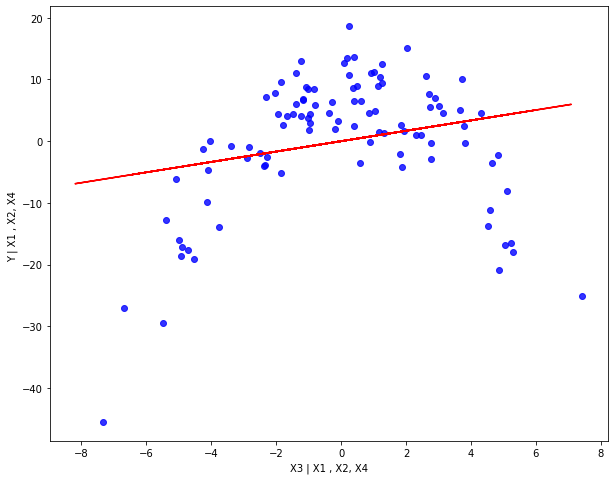

                                 OLS Regression Results                                
Dep. Variable:               resid_x3   R-squared (uncentered):                   0.055
Model:                            OLS   Adj. R-squared (uncentered):              0.046
Method:                 Least Squares   F-statistic:                              5.804
Date:                Sun, 23 Aug 2026   Prob (F-statistic):                      0.0178
Time:                        14:34:47   Log-Likelihood:                         -250.77
No. Observations:                 100   AIC:                                      503.5
Df Residuals:                      99   BIC:                                      506.2
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [255]:
slope = lmxall_y.params['x3']
y = 0 + slope*partialr['x3']

plt.figure(figsize=(10, 8))
plt.scatter(resid_x3, resid_y, alpha=0.8, color='blue')
plt.xlabel('X3 | X1 , X2, X4')
plt.ylabel('Y | X1 , X2, X4 ')
#plt.xlim([-4,4])
plt.plot(partialr['x3'], y, color='red')
plt.show()


#step3 
partial_df = pd.DataFrame({
    'resid_y': resid_y,
    'resid_x3': resid_x3
})
lmpartial = ols('resid_x3 ~ resid_y - 1', data = partial_df).fit()
print(lmpartial.summary())

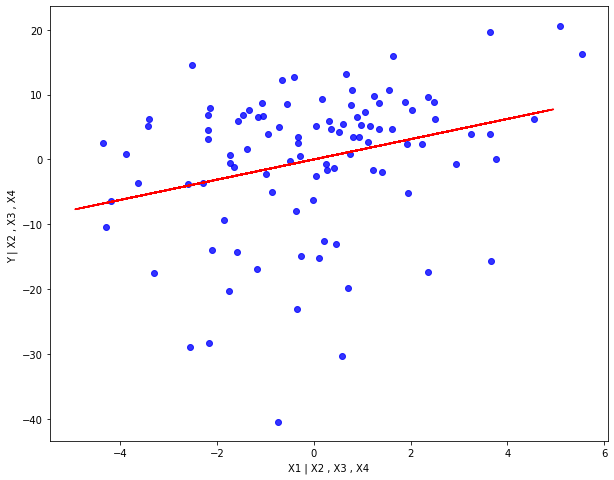

                                 OLS Regression Results                                
Dep. Variable:               resid_x1   R-squared (uncentered):                   0.085
Model:                            OLS   Adj. R-squared (uncentered):              0.076
Method:                 Least Squares   F-statistic:                              9.171
Date:                Sun, 23 Aug 2026   Prob (F-statistic):                     0.00314
Time:                        14:34:47   Log-Likelihood:                         -210.22
No. Observations:                 100   AIC:                                      422.4
Df Residuals:                      99   BIC:                                      425.1
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [256]:
# step 1 Remove the effect of other predictors from y, we regress
lmx234_y = ols('y ~ x2 + x3 + x4' , data = partialr).fit()

#we calculate the residuals

observed_y = partialr['y']
predicted_y = lmx234_y.fittedvalues
resid_y = observed_y - predicted_y

# Positive residual → the observed value was higher than predicted.
# Negative residual → the observed value was lower than predicted.
# Residual close to 0 → the prediction was very close to the observed value.

#step 2 We remove the effect of other predictors from x1, we regress 
lmx234_x = ols('x1 ~ x2 + x3 + x4', data = partialr).fit()
observed_x1 = partialr['x1']
predicted_x1 = lmx234_x.fittedvalues

#we then calculate the residuals again
resid_x1 = observed_x1 - predicted_x1

slope = lmxall_y.params['x1']
y = 0 + slope*partialr['x1']

plt.figure(figsize=(10, 8))
plt.scatter(resid_x1, resid_y, alpha=0.8, color='blue')
plt.xlabel('X1 | X2 , X3 , X4')
plt.ylabel('Y | X2 , X3 , X4 ')
#plt.xlim([-4,4])
plt.plot(partialr['x1'], y, color='red')
plt.show()


#step3 
partial_df = pd.DataFrame({
    'resid_y': resid_y,
    'resid_x1': resid_x1
})
lmpartial = ols('resid_x1 ~ resid_y - 1', data = partial_df).fit()
print(lmpartial.summary())

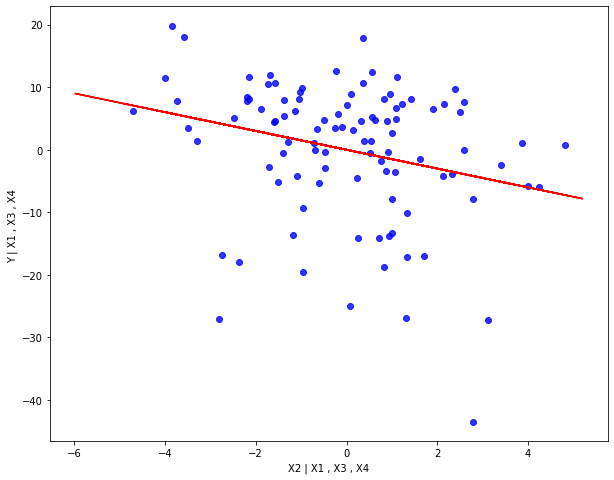

                                 OLS Regression Results                                
Dep. Variable:               resid_x2   R-squared (uncentered):                   0.069
Model:                            OLS   Adj. R-squared (uncentered):              0.060
Method:                 Least Squares   F-statistic:                              7.390
Date:                Sun, 23 Aug 2026   Prob (F-statistic):                     0.00774
Time:                        14:34:47   Log-Likelihood:                         -203.99
No. Observations:                 100   AIC:                                      410.0
Df Residuals:                      99   BIC:                                      412.6
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [257]:
# step 1 Remove the effect of other predictors from y, we regress
lmx134_y = ols('y ~ x1 + x3 + x4' , data = partialr).fit()

#we calculate the residuals

observed_y = partialr['y']
predicted_y = lmx134_y.fittedvalues
resid_y = observed_y - predicted_y

# Positive residual → the observed value was higher than predicted.
# Negative residual → the observed value was lower than predicted.
# Residual close to 0 → the prediction was very close to the observed value.

#step 2 We remove the effect of other predictors from x1, we regress 
lmx134_x = ols('x2 ~ x1 + x3 + x4', data = partialr).fit()
observed_x2 = partialr['x2']
predicted_x2 = lmx134_x.fittedvalues

#we then calculate the residuals again
resid_x2 = observed_x2 - predicted_x2

slope = lmxall_y.params['x2']
y = 0 + slope * partialr['x2']

plt.figure(figsize=(10, 8))
plt.scatter(resid_x2, resid_y, alpha=0.8, color='blue')
plt.xlabel('X2 | X1 , X3 , X4')
plt.ylabel('Y | X1 , X3 , X4 ')
#plt.xlim([-4,4])
plt.plot(partialr['x2'], y, color='red')
plt.show()


#step3 
partial_df = pd.DataFrame({
    'resid_y': resid_y,
    'resid_x2': resid_x2
})
lmpartial = ols('resid_x2 ~ resid_y - 1', data = partial_df).fit()
print(lmpartial.summary())

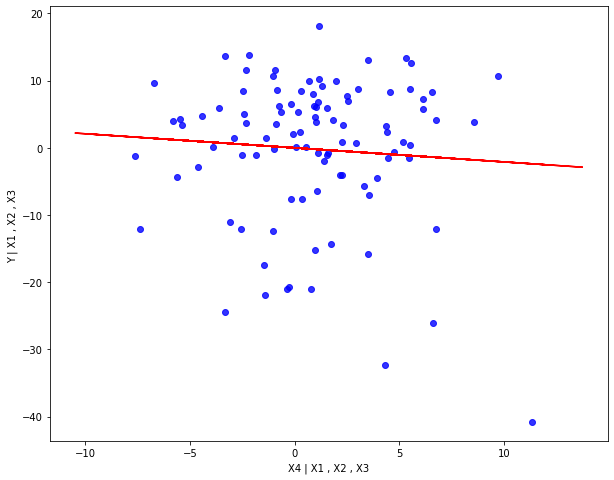

                                 OLS Regression Results                                
Dep. Variable:               resid_x4   R-squared (uncentered):                   0.004
Model:                            OLS   Adj. R-squared (uncentered):             -0.006
Method:                 Least Squares   F-statistic:                             0.4361
Date:                Sun, 23 Aug 2026   Prob (F-statistic):                       0.511
Time:                        14:34:47   Log-Likelihood:                         -275.09
No. Observations:                 100   AIC:                                      552.2
Df Residuals:                      99   BIC:                                      554.8
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [258]:
# step 1 Remove the effect of other predictors from y, we regress
lmx123_y = ols('y ~ x1 + x2 + x3' , data = partialr).fit()

#we calculate the residuals

observed_y = partialr['y']
predicted_y = lmx123_y.fittedvalues
resid_y = observed_y - predicted_y

# Positive residual → the observed value was higher than predicted.
# Negative residual → the observed value was lower than predicted.
# Residual close to 0 → the prediction was very close to the observed value.

#step 2 We remove the effect of other predictors from x1, we regress 
lmx123_x = ols('x4 ~ x1 + x2 + x3', data = partialr).fit()
observed_x4 = partialr['x4']
predicted_x4 = lmx134_x.fittedvalues

#we then calculate the residuals again
resid_x4 = observed_x4 - predicted_x4

slope = lmxall_y.params['x4']
y = 0 + slope * partialr['x4']

plt.figure(figsize=(10, 8))
plt.scatter(resid_x4, resid_y, alpha=0.8, color='blue')
plt.xlabel('X4 | X1 , X2 , X3')
plt.ylabel('Y | X1 , X2 , X3 ')
#plt.xlim([-4,4])
plt.plot(partialr['x4'], y, color='red')
plt.show()


#step3 
partial_df = pd.DataFrame({
    'resid_y': resid_y,
    'resid_x4': resid_x4
})
lmpartial = ols('resid_x4 ~ resid_y - 1', data = partial_df).fit()
print(lmpartial.summary())

<br>We see that the slope of the line is near 0 in the plot for x4, suggesting that x4 provides little to no additional information useful for predicting y that is not already contained in the other predictor variables. Further, in the plot for x3, we see that it has a clear non-linear relationship with y even after accounting for the effects of x1, x2, and x4. Thus, we may want to add a quadratic term or use splines to relax the linearity assumption for this variable.

In summary, added-variable plots depict the slope and the scatter of points around the partial regression line in an analogous way to bi-variate plots in simple linear regression. These plots can be helpful for:

- visualizing the effect of predictor variables (given everything else already in the model)
- diagnosing whether some variables have a non-linear relationship with the response variable
- identifying potential influential points and outliers (avPlots highlights these with the row number in the data set)
<br><br>__One downside to added-variable plots is that the scales on the x- and y-axis do not match the scales of the original variables in the regression model.__

####  Component + residual plots or partial residual plots ####

Component + residual plots, which are sometimes referred to as partial residual plots, offer a slightly different visualization by plotting $X_i\hat{\beta}_i+\hat{\epsilon}$ versus $X_i$, where $X_i$ is the $i^{\text{th}}$ predictor variable and is the variable of interest.

As shown below, $X_i\hat{\beta}_i+\hat{\epsilon}$ represents the part of $Y$ explained by $X_i$ that is not already explained by all the other predictors:

$Y-\sum_{j\ne i}X_j\hat{\beta}_j=\hat{Y}+\hat{\epsilon}-\sum_{j\ne i}X_j\hat{\beta}_j=X_i\hat{\beta}_i+\hat{\epsilon}$

There are a number of options in R for creating component + residual plots (see Section 3.14). This approach can be easily generalized to more complicated models that allow for non-linear relationships (e.g., quadratic terms), by replacing $X_i\hat{\beta}_i$ with multiple terms corresponding to the columns in the design matrix associated with the $i^{\text{th}}$ explanatory variable; however, component + residual plots are not appropriate if you include interactions in the model.

Component + residual plots are sometimes better than added-variable plots at diagnosing non-linearities, but they are not as good as added-variable plots at depicting the amount of variability explained by each predictor, given everything else in the model.

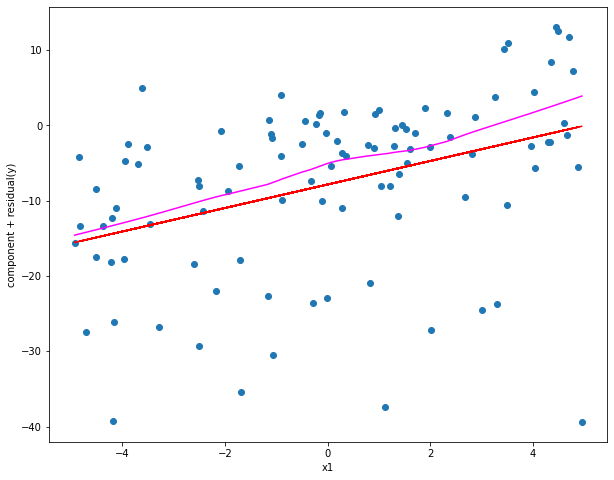

In [259]:
#step 1 for x1 ( we use the same dataset as above - partialr)
lmxall = ols('y ~ x1 + x2 + x3 + x4', data = partialr).fit()
x1 = partialr['x1']
x1_component = lmxall.params['Intercept'] + lmxall.params['x1'] * x1
resid = lmxall.resid
y = x1_component + resid
plt.figure(figsize=(10,8))
plt.plot(x1, x1_component, color='red', linestyle='dashed')

smoothed = lowess(
    endog=y,  # y-values
    exog=x1,  # x-values
    frac=0.6
)

lowess_x1 = smoothed[:, 0]
lowess_y = smoothed[:, 1]
plt.plot(lowess_x1, lowess_y, color='magenta')
plt.scatter(x1, y)
plt.xlabel('x1')
plt.ylabel('component + residual(y)')
plt.show()


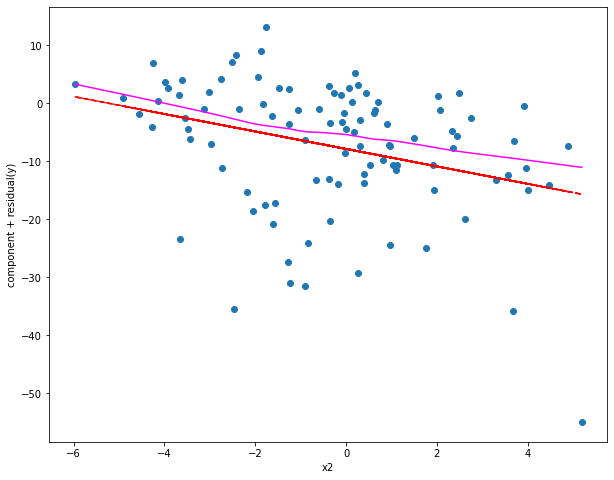

In [260]:
#step 1 for x1 ( we use the same dataset as above - partialr)
lmxall = ols('y ~ x1 + x2 + x3 + x4', data = partialr).fit()
x2 = partialr['x2']
x2_component = lmxall.params['Intercept'] + lmxall.params['x2'] * x2
resid = lmxall.resid
y = x2_component + resid
plt.figure(figsize=(10,8))
plt.plot(x2, x2_component, color='red', linestyle='dashed')

smoothed = lowess(
    endog=y,  # y-values
    exog=x2,  # x-values
    frac=0.6
)

lowess_x2 = smoothed[:, 0]
lowess_y = smoothed[:, 1]
plt.plot(lowess_x2, lowess_y, color='magenta')
plt.scatter(x2, y)
plt.xlabel('x2')
plt.ylabel('component + residual(y)')
plt.show()


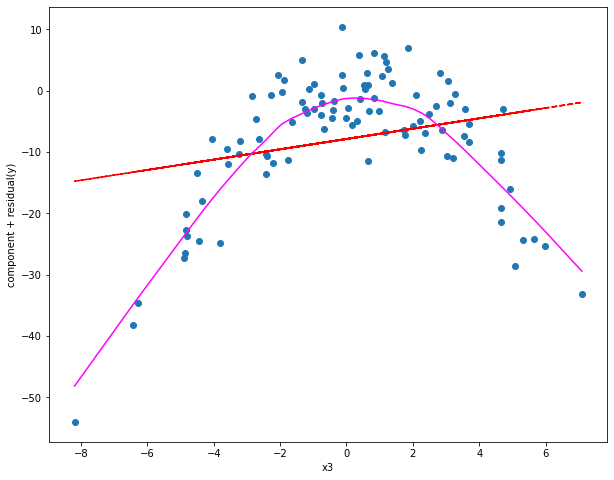

In [261]:
#step 1 for x1 ( we use the same dataset as above - partialr)
lmxall = ols('y ~ x1 + x2 + x3 + x4', data = partialr).fit()
x3 = partialr['x3']
x3_component = lmxall.params['Intercept'] + lmxall.params['x3'] * x3
resid = lmxall.resid
y = x3_component + resid
plt.figure(figsize=(10,8))
plt.plot(x3, x3_component, color='red', linestyle='dashed')

smoothed = lowess(
    endog=y,  # y-values
    exog=x3,  # x-values
    frac=0.6
)

lowess_x3 = smoothed[:, 0]
lowess_y = smoothed[:, 1]
plt.plot(lowess_x3, lowess_y, color='magenta')
plt.scatter(x3, y)
plt.xlabel('x3')
plt.ylabel('component + residual(y)')
plt.show()


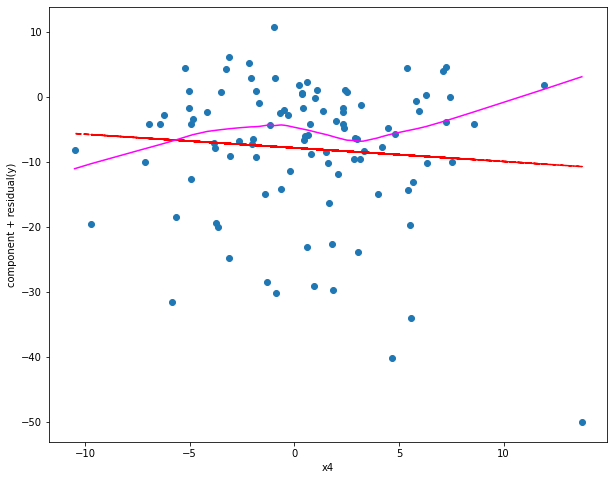

In [262]:
#step 1 for x1 ( we use the same dataset as above - partialr)
lmxall = ols('y ~ x1 + x2 + x3 + x4', data = partialr).fit()
x4 = partialr['x4']
x4_component = lmxall.params['Intercept'] + lmxall.params['x4'] * x4
resid = lmxall.resid
y = x4_component + resid
plt.figure(figsize=(10,8))
plt.plot(x4, x4_component, color='red', linestyle='dashed')

smoothed = lowess(
    endog=y,  # y-values
    exog=x4,  # x-values
    frac=0.6
)

lowess_x4 = smoothed[:, 0]
lowess_y = smoothed[:, 1]
plt.plot(lowess_x4, lowess_y, color='magenta')
plt.scatter(x4, y)
plt.xlabel('x4')
plt.ylabel('component + residual(y)')
plt.show()


#### Effect plots ####
Effect plots visualize predictions from a fitted regression model while focusing on one or more predictors of interest.

Suppose the fitted model is

$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_p X_p + \epsilon$.

If $X_1$ is the focal predictor, an adjusted effect plot varies $X_1$ across its observed range while holding the other predictors at fixed values, often their means for continuous variables and a selected or reference level for categorical variables.

For example, if the model is

$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \epsilon$,

then an adjusted prediction for $X_1$ can be calculated as

$\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1 X_1 + \hat{\beta}_2 \overline{X}_2 + \hat{\beta}_3 \overline{X}_3$,

where $X_1$ varies and $X_2$ and $X_3$ are held at their mean values.

The effect plot therefore shows

$x\text{-axis} = X_1$

and

$y\text{-axis} = \hat{Y}$.

The plot answers the question: “How does the fitted model predict $Y$ will change as $X_1$ changes, while the other predictors are held constant?”

If one of the non-focal predictors is categorical, for example $X_5$, predictions can be calculated for a selected category of $X_5$ while the continuous predictors are held fixed.

For example,

$\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1 X_1 + \hat{\beta}_2 \overline{X}_2 + \hat{\beta}_3 \overline{X}_3 + \text{effect of selected category of } X_5$.

If predictions are calculated separately for every category of $X_5$, the effect plot can contain one line for each category.

If there is no interaction between $X_1$ and $X_5$, the category-specific lines have the same slope but may have different vertical positions.

If the model contains an interaction,

$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_5 + \beta_3 X_1X_5 + \epsilon$,

then the effect of $X_1$ depends on the category of $X_5$, so the lines may have different slopes.

Marginal means are similar to adjusted means, but instead of fixing a categorical predictor at one category, predictions are calculated across its categories and then averaged.

For example, if $X_5$ has three categories, the marginal prediction at a particular value of $X_1$ is conceptually

$\hat{Y}{\text{marginal}} = \frac{\hat{Y}{X_5=1} + \hat{Y}{X_5=2} + \hat{Y}{X_5=3}}{3}$.

Thus:

$ \text{Adjusted effect} = \text{vary focal predictor and hold other predictors fixed}$

$ \text{Marginal effect} = \text{vary focal predictor and average predictions across levels of other categorical predictors}$

Unlike component + residual plots, effect plots are based on fitted model predictions and do not add residuals to the plotted values.

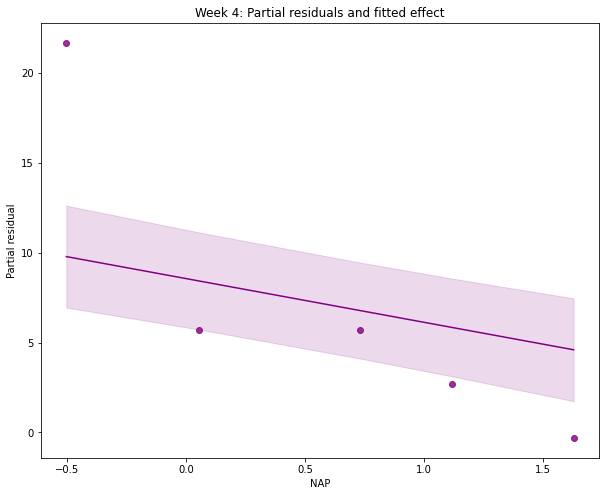

In [298]:
lm_effects = ols(
    'Richness ~ NAP + exposure + C(week)',
    data=rikz_full
).fit()

mask_w4 = rikz_full["week"] == 4

w4_nap = rikz_full.loc[mask_w4, "NAP"]

resid_w4 = lm_effects.resid.loc[mask_w4]


newdata_w4 = pd.DataFrame({
    "NAP": w4_nap,
    "exposure": rikz_full["exposure"].mean(),
    "week": 4
})


pred_w4 = lm_effects.predict(newdata_w4)

partial_w4 = pred_w4 + resid_w4


order = np.argsort(w4_nap.to_numpy())

x_sorted = w4_nap.to_numpy()[order]
pred_sorted = pred_w4.to_numpy()[order]
partial_sorted = partial_w4.to_numpy()[order]


pred_obj_w4 = lm_effects.get_prediction(newdata_w4)

pred_mean_w4 = np.asarray(pred_obj_w4.predicted_mean)

ci_w4 = pred_obj_w4.conf_int()

lower_w4 = ci_w4[:, 0]
upper_w4 = ci_w4[:, 1]

# sort them using the same NAP order
pred_mean_sorted = pred_mean_w4[order]
lower_sorted = lower_w4[order]
upper_sorted = upper_w4[order]
plt.figure(figsize=(10,8))
plt.fill_between(
    x_sorted,
    lower_sorted,
    upper_sorted,
    color="purple",
    alpha=0.15
)

plt.scatter(
    w4_nap,
    partial_w4,
    alpha=0.8,
    color="purple"
)

plt.plot(
    x_sorted,
    pred_sorted,
    color="purple"
)

plt.xlabel("NAP")
plt.ylabel("Partial residual")
plt.title("Week 4: Partial residuals and fitted effect")
plt.show()

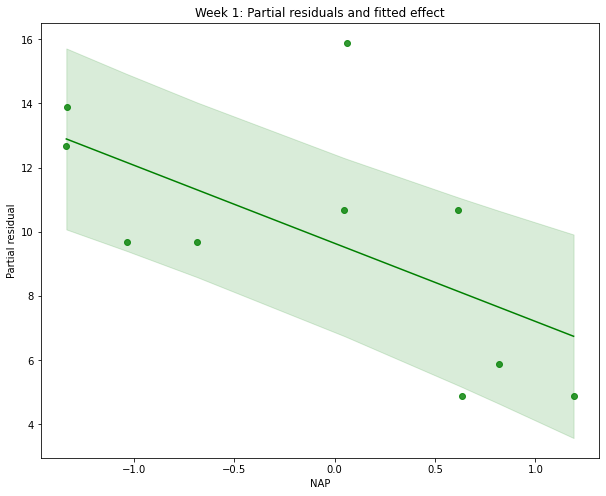

In [299]:
mask_w1 = rikz_full["week"] == 1

w1_nap = rikz_full.loc[mask_w1, "NAP"]

resid_w1 = lm_effects.resid.loc[mask_w1]


newdata_w1 = pd.DataFrame({
    "NAP": w1_nap,
    "exposure": rikz_full["exposure"].mean(),
    "week": 1
})


pred_w1 = lm_effects.predict(newdata_w1)

partial_w1 = pred_w1 + resid_w1


order = np.argsort(w1_nap.to_numpy())

x_sorted = w1_nap.to_numpy()[order]
pred_sorted = pred_w1.to_numpy()[order]
partial_sorted = partial_w1.to_numpy()[order]


pred_obj_w1 = lm_effects.get_prediction(newdata_w1)

pred_mean_w1 = np.asarray(pred_obj_w1.predicted_mean)

ci_w1 = pred_obj_w1.conf_int()

lower_w1 = ci_w1[:, 0]
upper_w1 = ci_w1[:, 1]

pred_mean_sorted = pred_mean_w1[order]
lower_sorted = lower_w1[order]
upper_sorted = upper_w1[order]


plt.figure(figsize=(10,8))

plt.fill_between(
    x_sorted,
    lower_sorted,
    upper_sorted,
    color="green",
    alpha=0.15
)

plt.scatter(
    w1_nap,
    partial_w1,
    alpha=0.8,
    color="green"
)

plt.plot(
    x_sorted,
    pred_sorted,
    color="green"
)

plt.xlabel("NAP")
plt.ylabel("Partial residual")
plt.title("Week 1: Partial residuals and fitted effect")
plt.show()

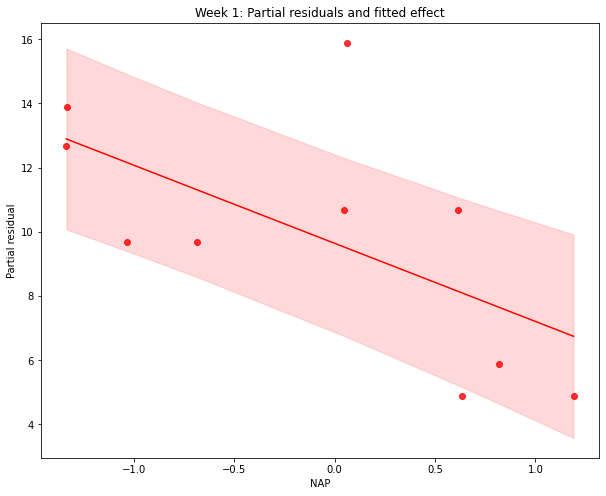

In [301]:
mask_w1 = rikz_full["week"] == 1

w1_nap = rikz_full.loc[mask_w1, "NAP"]

resid_w1 = lm_effects.resid.loc[mask_w1]


newdata_w1 = pd.DataFrame({
    "NAP": w1_nap,
    "exposure": rikz_full["exposure"].mean(),
    "week": 1
})


pred_w1 = lm_effects.predict(newdata_w1)

partial_w1 = pred_w1 + resid_w1


order_w1 = np.argsort(w1_nap.to_numpy())

x_sorted_w1 = w1_nap.to_numpy()[order_w1]
pred_sorted_w1 = pred_w1.to_numpy()[order_w1]
partial_sorted_w1 = partial_w1.to_numpy()[order_w1]


pred_obj_w1 = lm_effects.get_prediction(newdata_w1)

pred_mean_w1 = np.asarray(pred_obj_w1.predicted_mean)

ci_w1 = pred_obj_w1.conf_int()

lower_w1 = ci_w1[:, 0]
upper_w1 = ci_w1[:, 1]


pred_mean_sorted_w1 = pred_mean_w1[order_w1]
lower_sorted_w1 = lower_w1[order_w1]
upper_sorted_w1 = upper_w1[order_w1]


plt.figure(figsize=(10, 8))

plt.fill_between(
    x_sorted_w1,
    lower_sorted_w1,
    upper_sorted_w1,
    color="red",
    alpha=0.15
)

plt.scatter(
    w1_nap,
    partial_w1,
    alpha=0.8,
    color="red"
)

plt.plot(
    x_sorted_w1,
    pred_sorted_w1,
    color="red"
)

plt.xlabel("NAP")
plt.ylabel("Partial residual")
plt.title("Week 1: Partial residuals and fitted effect")
plt.show()

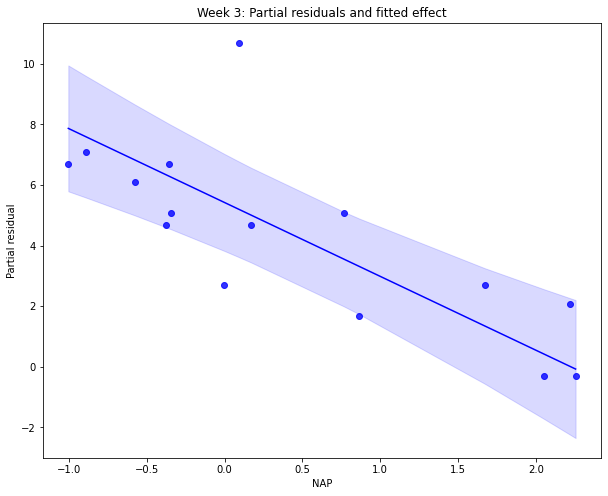

In [302]:
mask_w3 = rikz_full["week"] == 3

w3_nap = rikz_full.loc[mask_w3, "NAP"]

resid_w3 = lm_effects.resid.loc[mask_w3]


newdata_w3 = pd.DataFrame({
    "NAP": w3_nap,
    "exposure": rikz_full["exposure"].mean(),
    "week": 3
})


pred_w3 = lm_effects.predict(newdata_w3)

partial_w3 = pred_w3 + resid_w3


order_w3 = np.argsort(w3_nap.to_numpy())

x_sorted_w3 = w3_nap.to_numpy()[order_w3]
pred_sorted_w3 = pred_w3.to_numpy()[order_w3]
partial_sorted_w3 = partial_w3.to_numpy()[order_w3]


pred_obj_w3 = lm_effects.get_prediction(newdata_w3)

pred_mean_w3 = np.asarray(pred_obj_w3.predicted_mean)

ci_w3 = pred_obj_w3.conf_int()

lower_w3 = ci_w3[:, 0]
upper_w3 = ci_w3[:, 1]


pred_mean_sorted_w3 = pred_mean_w3[order_w3]
lower_sorted_w3 = lower_w3[order_w3]
upper_sorted_w3 = upper_w3[order_w3]


plt.figure(figsize=(10, 8))

plt.fill_between(
    x_sorted_w3,
    lower_sorted_w3,
    upper_sorted_w3,
    color="blue",
    alpha=0.15
)

plt.scatter(
    w3_nap,
    partial_w3,
    alpha=0.8,
    color="blue"
)

plt.plot(
    x_sorted_w3,
    pred_sorted_w3,
    color="blue"
)

plt.xlabel("NAP")
plt.ylabel("Partial residual")
plt.title("Week 3: Partial residuals and fitted effect")
plt.show()